### **LangGraph:**
- LangGraph is a Framework(Library) in langchain ecosystem by using which users can create AI workFlows.(Easy to complex) by using Graphs[State graph]

- Instead of simple chains → you design a graph with nodes + edges + state.

### ***State Graph(Graphical Structure):***

- Entire application that are created by Graphical Structure

- It have 3 important components:
1. state: Actually represent--> Data.


2. Nodes: Actually represent--> Step/Task --> Based on task --> perform Action --> For that programmatically use (Python Function).

3. Edges: Actually represent--> Flow of the data through the graph --> Use to connect nodes --> To tell the data where to go.



## ***1. Simple Sequential Workflow***

A basic step-by-step flow where each step runs one after another in a fixed order.


👉 No intelligence or decision-making

👉 Output of one step → input of next step

Example:
Step 1 → Step 2 → Step 3 → Final Output

## ***Step 1 : Understand the Problem Statements***

In [ ]:
# Create a calculator

In [ ]:
!pip install langchain langgraph

## ***Step 2 : Create a state***
- Using PyDantic/TypeDict : Mostly we are using Pydantic: Create our own schema using them (Template).

- They define the structure, type, and rules of your state (shared memory) so every node in the graph works consistently and safely.

In [ ]:
from typing import TypedDict

# They define the structure, type, and rules of your state (shared memory) so every node in the graph works consistently and safely.

In [ ]:
# Create a state schema
# we need to follow above function rules
class Data(TypedDict):
  number1:float
  number2:float
  operator:str
  output:float

# It will return o/p in the form of Dictionary {"number1":10,"number2":20,"operator":"+"}

In [ ]:
data= Data(number1=10,number2=20,operator="-")

## ***Step 3: Create a State Graph Object***

- With the help of state graph object we can able create entire state graph.
- This object will tell how to add nodws, how to add edges so the final graph will be designed

In [ ]:
from langgraph.graph import StateGraph,START,END

In [ ]:
graph = StateGraph(state_schema = Data) # Data --> Schema

# We have created a state graph objects which will only allow data as the schema to flow

## ***Step 4: Create Graph using Nodes(Steps) and Edges(connection)***

In [ ]:
# Deigned Nodes
# create a variable called state which is hold the Data
# we created a function which is act as a node
def math_operation(state:Data):
  if state["operator"]=="+":
    state["output"] = state["number1"]+state["number2"]
  elif state["operator"]=="-":
    state["output"] = state["number1"]-state["number2"]
  elif state["operator"]=="*":
    state["output"] = state["number1"]*state["number2"]
  elif state["operator"]=="/":
    state["output"] = state["number1"]/state["number2"]
  else:
    state["output"] = "Invalid Operator"

  return state
# This is a logic to perform action

#Note: Each node take state as a input and generate output

In [ ]:
graph.add_node("math_operation",math_operation) #Here we are adding "math_operation" node into the graph

#### ***Graph structure***
**START NODE --> math_operation Node--> END NODE**

- START AND END NODE both are default nodes

In [ ]:
# Create edges between nodes
graph.add_edge(START,"math_operation")
graph.add_edge("math_operation",END)

## ***Step 5 : Compile the graph***

In [ ]:
state_graph = graph.compile()

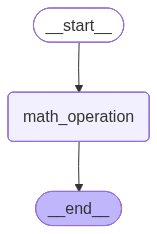

In [ ]:
state_graph

## ***Step 6 : Start the graph --> Invoke(data)***

In [ ]:
state_graph.invoke(data)

{'number1': 10, 'number2': 20, 'operator': '-', 'output': -10}

In [ ]:
#OR
state_graph.invoke({'number1': 10, 'number2': 20, 'operator': '-'})

{'number1': 10, 'number2': 20, 'operator': '-', 'output': -10}

In [ ]:
state_graph.invoke({'number1': 30, 'number2': 20, 'operator': '+'})

{'number1': 30, 'number2': 20, 'operator': '+', 'output': 50}

In [ ]:
# Another example:

from array import array

In [ ]:
class Data1(TypedDict):
  imgpath:str
  height:int
  width:int
  output:array

In [ ]:
graph = StateGraph(state_schema =Data1)

In [ ]:
# design two nodes
import cv2
def resize(state:Data1):
  img = cv2.imread(state["imgpath"])
  img = cv2.resize(img,(state["height"],state["width"]))
  state["output"] = img
  return state

def filter(state:Data1):
  img = cv2.cvtColor(state["output"],cv2.COLOR_BGR2GRAY)
  state["output"]=img
  return state


In [ ]:
# Add the node
graph.add_node("resize",resize)
graph.add_node("filter",filter)

In [ ]:
# Create edges between nodes
graph.add_edge(START,"resize")
graph.add_edge("resize","filter")
graph.add_edge("filter",END)

In [ ]:
state_graph = graph.compile()

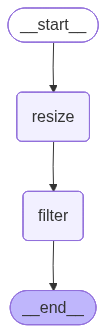

In [ ]:
state_graph

In [ ]:
output = state_graph.invoke({"imgpath":"/content/shin chan desktop wallpaper.jpeg", "height":100 ,"width":100})

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
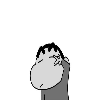

In [ ]:
output["output"]